In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [70]:
#Beam A
b_A = 19.5 #mm
d_A = 5.58 #mm
l_A = 1140 #mm
A = {"b":b_A, "d":d_A, "l":l_A}

#Beam B
b_B = 19.36 #mm
d_B = 3.4 #mm
l_B = 1140 #mm
B = {"b":b_B, "d":d_B, "l":l_B}

step3 = {"beam":A,
         "L":710, #mm
         "W":np.array([100,200,300,400,500])/1000*9.81, #N
         "delta":np.array([11,24,36,50,61])*0.01 #mm
         }

step4 = {"beam":A,
         "L":np.array([710,660,610,560,460]),
         "W":500/1000*9.81, #N
         "delta":np.array([0.62,0.49,0.39,0.30,0.18])
         }

step5 = {"beam":np.array([A,B]),
         "L":510,
         "W":500/1000*9.81,
         "delta":np.array([0.05,0.28])
         }

step6 = {"beam":B,
         "L":510,
         "W":np.array([100,200,300,400,500])/1000*9.81,
         "delta":np.array([0.15,0.38,0.58,0.79,1.01]),
         "c":100
         }

step7i = {"beam":B,
          "W":500/1000*9.81,
          "a":100,
          "b":355,
          "delta":0.05
          }

step7ii = {"beam":B,
           "W":500/1000*9.81,
           "a":355,
           "b":100,
           "delta":0.06
           }

step7iii = {"beam":B,
            "W":500/1000*9.81,
            "a":np.array([80,120,160,200,240]),
            "b":np.array([285,315,345,375,405]),
            "delta_a":np.array([0.37,0.79,0.81,0.75,0.79]),
            "delta_b":np.array([0.88,0.80,0.71,0.67,0.15])
            }

step3 = {"beam":A,
         "L":710, #mm
         "W":np.array([100,200,300,400,500])/1000*9.81, #N
         "delta":np.array([13,23,35,46,63])*0.01 #mm
         }


I_A = b_A*d_A**3/12
I_B = b_B*d_B**3/12
A["I"] = I_A
B["I"] = I_B

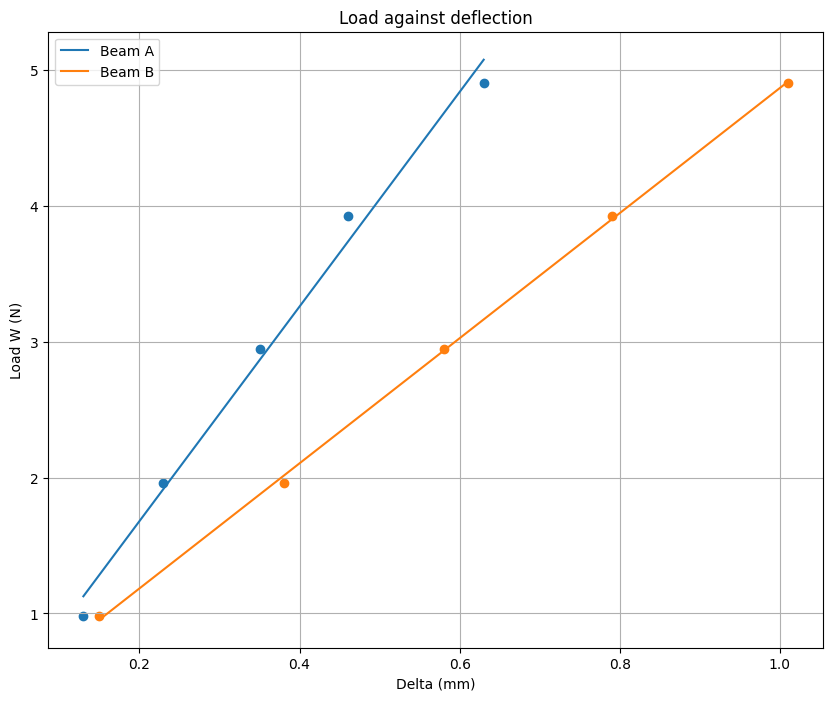

Young's Modulus of Beam A = 208558.8441317146 N/mm^2 = 208.5588441317146 GPa
Young's Modulus of Beam B = 236046.2317769042 N/mm^2 = 236.0462317769042 GPa


In [71]:
plt.figure(figsize=(10,8))

plt.scatter(step3['delta'],step3['W'])
m3,c3 = np.polyfit(step3['delta'],step3['W'],1)
plt.plot(step3['delta'],step3['delta']*m3+c3, label="Beam A")

plt.scatter(step6['delta'],step6['W'])
m6,c6 = np.polyfit(step6['delta'],step6['W'],1)
plt.plot(step6['delta'],step6['delta']*m6+c6, label="Beam B")


plt.title("Load against deflection")
plt.xlabel("Delta (mm)")
plt.ylabel("Load W (N)")
plt.legend()
plt.grid(True)
plt.show()

E_A_3 = m3*step3['L']**3 / (A['I']*48)
E_B_6 = step6['c']*step6['L']**2*m6/(8*step6['beam']['I'])
print("Young's Modulus of Beam A =",E_A_3, "N/mm^2 =", E_A_3*1e-3, "GPa")
print("Young's Modulus of Beam B =",E_B_6, "N/mm^2 =", E_B_6*1e-3, "GPa")

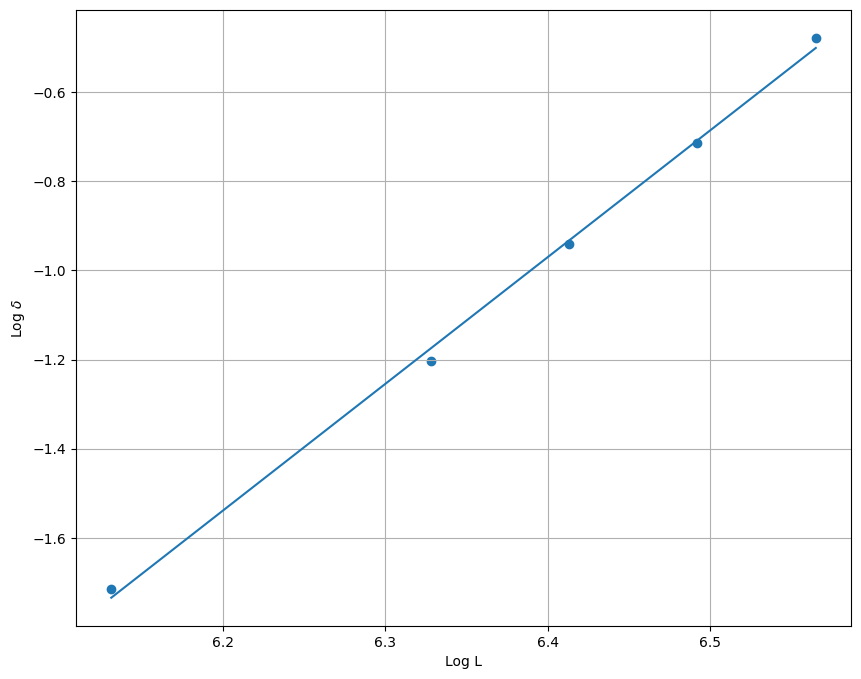

gradient =  2.8418085867134524 ~3 - This confirms that deflection is propotional to L^3
Young's Modulus of Beam A = 75674.37434498785 N/mm^2 = 75.67437434498785 GPa - very different from the 208Gpa I obtained above


In [72]:
x = np.log(step4['L'])
y = np.log(step4['delta'])

plt.figure(figsize=(10,8))

plt.scatter(x,y)
m4,c4 = np.polyfit(x,y,1)
plt.plot(x,x*m4+c4)

plt.xlabel('Log L')
plt.ylabel(r'Log $\delta$')
plt.grid(True)
plt.show()

E_A_4 = step4['W']/(48*step4['beam']['I']*np.exp(c4))
print("gradient = ", m4, "~3 - This confirms that deflection is propotional to L^3")
print("Young's Modulus of Beam A =",E_A_4, "N/mm^2 =", E_A_4*1e-3, "GPa - very different from the 208Gpa I obtained above")

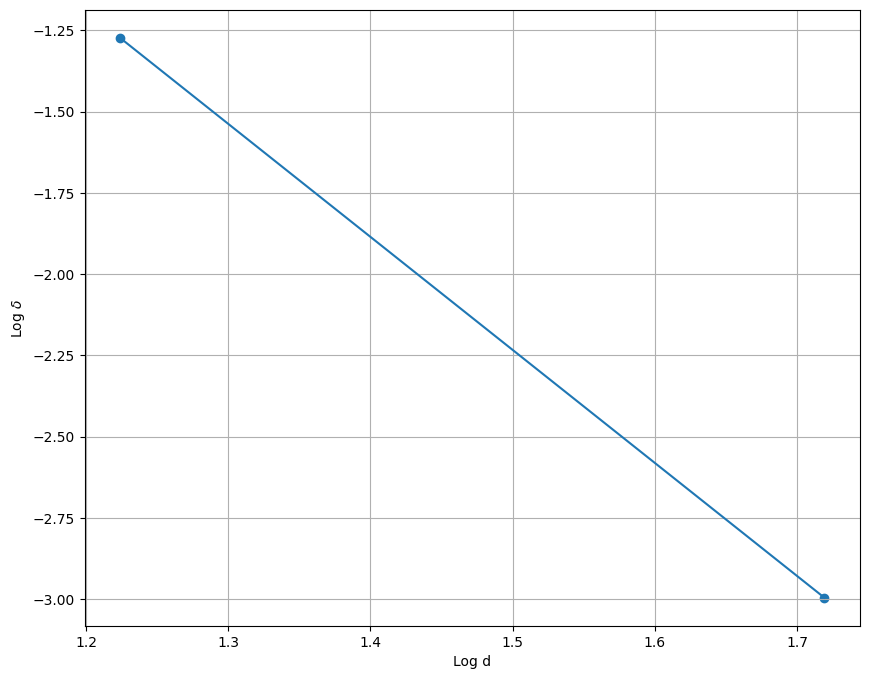

gradient = -3.4774327658393505 ~ -3 This confirms that deflection is propotional to d^-3


In [73]:
x = np.log(np.array([A['d'], B['d']]))
y = np.log(step5['delta'])

plt.figure(figsize=(10,8))

plt.scatter(x,y)
m5,c5 = np.polyfit(x,y,1)
plt.plot(x,x*m5+c5)

plt.xlabel('Log d')
plt.ylabel(r'Log $\delta$')
plt.grid(True)
plt.show()

print('gradient =', m5, "~ -3", "This confirms that deflection is propotional to d^-3")